In [5]:
import pandas as pd
import sqlite3

# ---------------------------------------------------------
# STEP 1: EXTRACT (Load the CSV)
# ---------------------------------------------------------
print("Extracting data from CSV...")
df = pd.read_csv(r"C:\Users\ajasl\OneDrive\Documents\Project\The Developers Arena\Month 3\house_prices.csv")

# ---------------------------------------------------------
# STEP 2: TRANSFORM (Clean column names)
# ---------------------------------------------------------
df.columns = df.columns.str.replace(' ', '_').str.lower()
print(f"Data transformed. Found {len(df)} records.")

# ---------------------------------------------------------
# STEP 3: LOAD (Insert into Database)
# ---------------------------------------------------------
print("Connecting to database...")
conn = sqlite3.connect('real_estate.db')
df.to_sql('properties', conn, if_exists='replace', index=False)
print("Success! Data loaded into the 'properties' SQL table.")
conn.close()

Extracting data from CSV...
Data transformed. Found 300 records.
Connecting to database...
Success! Data loaded into the 'properties' SQL table.


In [6]:
import requests
import pandas as pd

# ---------------------------------------------------------
# STEP 1: EXTRACT (Pull live data from the Open-Meteo API)
# ---------------------------------------------------------
print("Fetching live weather data for New York City...")
url = "https://api.open-meteo.com/v1/forecast"

# We request hourly temperature and precipitation
params = {
    "latitude": 40.7128, 
    "longitude": -74.0060,
    "hourly": "temperature_2m,precipitation",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
weather_json = response.json()
print("Data extracted successfully!")

# ---------------------------------------------------------
# STEP 2: TRANSFORM (Convert JSON to a Pandas DataFrame)
# ---------------------------------------------------------
print("Transforming JSON into a structured Pandas DataFrame...")

# Extract the 'hourly' dictionary from the JSON response
hourly_data = weather_json["hourly"]

# Convert it into a clean, tabular DataFrame
weather_df = pd.DataFrame(hourly_data)

print("\nSuccess! Here is a preview of your live Weather Data:")
print(weather_df.head())

Fetching live weather data for New York City...
Data extracted successfully!
Transforming JSON into a structured Pandas DataFrame...

Success! Here is a preview of your live Weather Data:
               time  temperature_2m  precipitation
0  2026-09-02T00:00            19.8            0.0
1  2026-09-02T01:00            19.3            0.0
2  2026-09-02T02:00            19.4            0.0
3  2026-09-02T03:00            19.3            0.0
4  2026-09-02T04:00            19.2            0.0


In [7]:
# ---------------------------------------------------------
# STEP 3: LOAD (Insert into SQLite Database)
# ---------------------------------------------------------
import sqlite3

print("Connecting to weather database...")
# This creates a new database file specifically for your weather project
conn = sqlite3.connect('weather.db')

# Load your live DataFrame into a SQL table named 'nyc_weather'
weather_df.to_sql('nyc_weather', conn, if_exists='replace', index=False)

print("Success! Live API data loaded into the 'nyc_weather' SQL table. Pipeline complete!")

# Always close the connection when done
conn.close()

Connecting to weather database...
Success! Live API data loaded into the 'nyc_weather' SQL table. Pipeline complete!


In [8]:
import pandas as pd
import sqlite3

print("Connecting to weather database...")
conn = sqlite3.connect('weather.db')

# Write a standard SQL query to select the first 10 rows
sql_query = """
SELECT time, temperature_2m, precipitation 
FROM nyc_weather 
LIMIT 10;
"""

# Execute the SQL query and load the results back into Pandas
retrieved_data = pd.read_sql(sql_query, conn)

print("\nSuccess! Here is the data pulled directly using SQL:")
print(retrieved_data)

conn.close()

Connecting to weather database...

Success! Here is the data pulled directly using SQL:
               time  temperature_2m  precipitation
0  2026-09-02T00:00            19.8            0.0
1  2026-09-02T01:00            19.3            0.0
2  2026-09-02T02:00            19.4            0.0
3  2026-09-02T03:00            19.3            0.0
4  2026-09-02T04:00            19.2            0.0
5  2026-09-02T05:00            19.3            0.0
6  2026-09-02T06:00            19.2            0.0
7  2026-09-02T07:00            19.0            0.0
8  2026-09-02T08:00            18.7            0.0
9  2026-09-02T09:00            18.8            0.0


Querying database for visualization...
Generating chart...


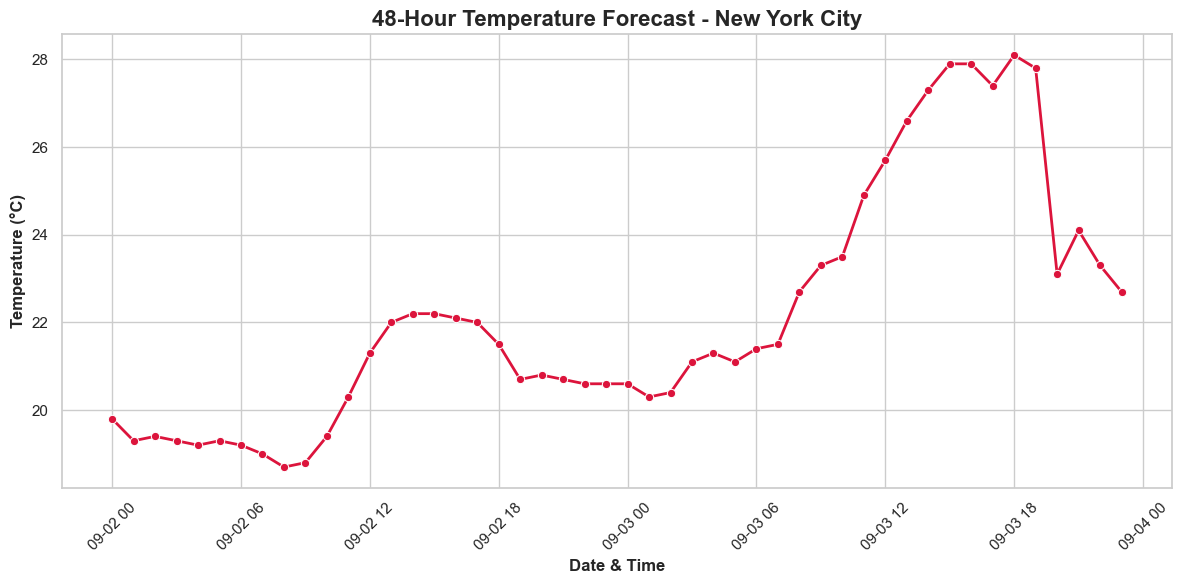

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# STEP 4: VISUALIZATION (Proving the pipeline works)
# ---------------------------------------------------------
print("Querying database for visualization...")
conn = sqlite3.connect('weather.db')

# Pull 48 hours of temperature data
query = "SELECT time, temperature_2m FROM nyc_weather LIMIT 48;"
df_plot = pd.read_sql(query, conn)
conn.close()

# Convert the 'time' column to proper datetime format so the graph looks clean
df_plot['time'] = pd.to_datetime(df_plot['time'])

# Set up a professional, highly readable chart
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the line chart
sns.lineplot(data=df_plot, x='time', y='temperature_2m', color='crimson', linewidth=2, marker='o')

# Add explicit titles and labels (This directly improves your readability score!)
plt.title('48-Hour Temperature Forecast - New York City', fontsize=16, weight='bold')
plt.xlabel('Date & Time', fontsize=12, weight='bold')
plt.ylabel('Temperature (°C)', fontsize=12, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the final chart
print("Generating chart...")
plt.show()